In [1]:
import pandas as pd
import sys
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path.cwd().parent))

path = "../data/raw/base_enespersonas.csv"

df = pd.read_csv(path, sep=";")
df = df[["v109", "v182caes", "v183ciuo", "v183cno"]]
df

,v109,v182caes,v183ciuo,v183cno
0,1.0,8401.0,3120.0,72203.0
1,2.0,8501.0,2330.0,41312.0
2,2.0,4804.0,5223.0,30314.0
3,1.0,800.0,8111.0,70313.0
4,2.0,NaN,NaN,NaN
...,...,...,...,...
27610,2.0,NaN,NaN,NaN
27611,2.0,NaN,NaN,NaN
27612,2.0,NaN,NaN,NaN
27613,1.0,NaN,NaN,NaN


In [2]:
# Limpieza básica
df_copy = df.copy()
df_copy = df_copy.dropna(subset=["v109", "v182caes", "v183ciuo", "v183cno"], how="any")
df_copy["v109"] = df_copy["v109"].astype(int)
df_copy["v182caes"] = df_copy["v182caes"].astype(int)
df_copy["v183ciuo"] = df_copy["v183ciuo"].astype(int)
df_copy["v183cno"] = df_copy["v183cno"].astype(int)
df_copy = df_copy[
	(df_copy["v182caes"] < 9999)
	& (df_copy["v183ciuo"] < 9999)
	& (df_copy["v183cno"] < 99999)
]
df_copy

,v109,v182caes,v183ciuo,v183cno
0,1,8401,3120,72203
1,2,8501,2330,41312
2,2,4804,5223,30314
3,1,800,8111,70313
5,2,4803,5223,30313
...,...,...,...,...
27593,1,8403,5223,30324
27598,1,4502,7132,72313
27601,2,4808,5230,20313
27602,2,4808,5230,20313


In [3]:
df_copy.describe()

,v109,v182caes,v183ciuo,v183cno
count,15543.000000,15543.000000,15543.000000,15543.000000
mean,1.470501,5976.263398,5943.546484,46420.979155
std,0.499660,2795.087219,2353.895587,23141.013502
min,1.000000,100.000000,110.000000,1001.000000
25%,1.000000,4000.000000,4214.000000,30314.000000
50%,1.000000,5300.000000,5321.000000,47333.000000
75%,2.000000,8501.000000,8142.000000,60314.000000
max,3.000000,9700.000000,9629.000000,92393.000000


In [4]:
df_cno_to_ciuo = (
	df_copy.groupby(by=["v183cno"])
	.agg({"v183ciuo": lambda x: sorted(x.unique().tolist())})
	.reset_index()
)
df_cno_to_ciuo["v183ciuo_len"] = df_cno_to_ciuo["v183ciuo"].apply(
	lambda x: len(x) if isinstance(x, list) else 0
)
df_cno_to_ciuo = df_cno_to_ciuo.sort_values(by="v183ciuo_len", ascending=False)
df_cno_to_ciuo

,v183cno,v183ciuo,v183ciuo_len
4,5002,"[1321, 1322, 1324, 1345, 1411, 1412, 1420, 143...",109
5,6001,"[1120, 1210, 1221, 1311, 1320, 1321, 1322, 132...",88
483,80313,"[3134, 3142, 3333, 5120, 5153, 5223, 7115, 720...",73
486,80323,"[3122, 3135, 4110, 4419, 5221, 5322, 7112, 711...",69
3,5001,"[1311, 1321, 1345, 1346, 1411, 1420, 2133, 214...",56
...,...,...,...
296,51311,[3422],1
300,51331,[2641],1
301,51333,[3422],1
302,52112,[5311],1


In [5]:
df_cno_to_ciuo[df_cno_to_ciuo["v183ciuo_len"] <= 1]

,v183cno,v183ciuo,v183ciuo_len
418,64113,[6222],1
520,90123,[7127],1
417,63323,[6122],1
477,80192,[8183],1
419,64313,[6220],1
...,...,...,...
296,51311,[3422],1
300,51331,[2641],1
301,51333,[3422],1
302,52112,[5311],1


Por los menos 178 codigos CNO (v183cno) estan asociado a un solo codigo CIUO (v183ciuo). Esto sugiere que, al menos para esos casos, el CNO es un buen proxy del CIUO. Sin embargo, hay algunos casos donde un mismo CNO esta asociado a multiples CIUO, para ello, vamos explorar la posibilidad de deducirlo a partir de la informacion de la rama de actividad economica (v182caes).

In [6]:
df_cno_to_ciuo[df_cno_to_ciuo["v183ciuo_len"] > 1]

,v183cno,v183ciuo,v183ciuo_len
4,5002,"[1321, 1322, 1324, 1345, 1411, 1412, 1420, 143...",109
5,6001,"[1120, 1210, 1221, 1311, 1320, 1321, 1322, 132...",88
483,80313,"[3134, 3142, 3333, 5120, 5153, 5223, 7115, 720...",73
486,80323,"[3122, 3135, 4110, 4419, 5221, 5322, 7112, 711...",69
3,5001,"[1311, 1321, 1345, 1346, 1411, 1420, 2133, 214...",56
...,...,...,...
449,72133,"[7131, 9313]",2
492,80392,"[2163, 3116]",2
298,51313,"[5164, 6121]",2
248,46314,"[5100, 9412]",2


In [7]:
# Cantidad de ocurrencias de cada combinaciones de v182caes, v183ciuo, and v183cno
df_counts = (
	df_copy.groupby(by=["v182caes", "v183ciuo", "v183cno"])
	.size()
	.reset_index(name="count")
	.sort_values(by="count", ascending=False)
)
df_counts

,v182caes,v183ciuo,v183cno,count
5128,9700,9111,55314,1114
1584,4000,7112,72313,319
4177,8501,2341,41312,258
5098,9700,5311,57314,195
1741,4000,9313,72314,155
...,...,...,...,...
2611,4901,8311,34313,1
810,1800,2166,80333,1
2613,4901,8311,34393,1
2614,4901,8312,34313,1


In [8]:
df_ciuo = (
	df_copy.groupby(by=["v182caes", "v183cno"])
	.size()
	.reset_index(name="count")
	.sort_values(by="count", ascending=False)
)
df_ciuo

,v182caes,v183cno,count
3104,9700,55314,1258
2584,8501,41312,629
1006,4000,72313,454
993,4000,72113,295
3112,9700,57314,273
...,...,...,...
1250,4802,80123,1
1255,4803,10313,1
1257,4803,20203,1
1259,4803,20323,1


In [9]:
df_cno_caes_to_ciuo = (
	df_copy.groupby(by=["v182caes", "v183cno"])
	.agg({"v183ciuo": lambda x: dict(Counter(sorted(x.tolist())))})
	.reset_index()
)
df_cno_caes_to_ciuo["v183ciuo_len"] = df_cno_caes_to_ciuo["v183ciuo"].apply(
	lambda x: len(x) if isinstance(x, dict) else 0
)
df_cno_caes_to_ciuo = df_cno_caes_to_ciuo.sort_values(
	by="v183ciuo_len", ascending=False
)
df_cno_caes_to_ciuo

,v182caes,v183cno,v183ciuo,v183ciuo_len
1006,4000,72313,"{5153: 1, 7110: 4, 7111: 4, 7112: 319, 7113: 1...",26
2372,8401,10333,"{3342: 2, 3343: 3, 3351: 2, 3352: 1, 3411: 4, ...",22
1009,4000,72323,"{6113: 1, 7110: 4, 7111: 1, 7112: 132, 7113: 1...",21
993,4000,72113,"{3112: 1, 3123: 1, 5222: 1, 7110: 2, 7111: 2, ...",20
954,4000,5002,"{3112: 6, 3333: 2, 7110: 1, 7111: 2, 7112: 60,...",19
...,...,...,...,...
1204,4801,30312,{3324: 1},1
1205,4801,30313,{5223: 4},1
1207,4801,30324,{5223: 2},1
1208,4801,30333,{5223: 2},1


In [10]:
df_cno_caes_to_ciuo.to_csv("../data/processed/cno_caes_to_ciuo.csv", index=False)

In [11]:
df_unique_cnos = df_cno_caes_to_ciuo[df_cno_caes_to_ciuo["v183ciuo_len"] <= 1]
df_unique_cnos

,v182caes,v183cno,v183ciuo,v183ciuo_len
1887,6000,45131,{2654: 1},1
2213,7800,10312,{3333: 1},1
2072,6900,56314,{9112: 2},1
2212,7800,6001,{3333: 1},1
2203,7701,30113,{5221: 1},1
...,...,...,...,...
1204,4801,30312,{3324: 1},1
1205,4801,30313,{5223: 4},1
1207,4801,30324,{5223: 2},1
1208,4801,30333,{5223: 2},1


In [12]:
df_cno_caes_sex_to_ciuo = (
	df_copy.groupby(by=["v109", "v182caes", "v183cno"])
	.agg({"v183ciuo": lambda x: dict(Counter(sorted(x.tolist())))})
	.reset_index()
)
df_cno_caes_sex_to_ciuo["v183ciuo_len"] = df_cno_caes_sex_to_ciuo["v183ciuo"].apply(
	lambda x: len(x) if isinstance(x, dict) else 0
)
df_cno_caes_sex_to_ciuo = df_cno_caes_sex_to_ciuo.sort_values(
	by="v183ciuo_len", ascending=False
)
df_cno_caes_sex_to_ciuo.to_csv(
	"../data/processed/cno_caes_sex_to_ciuo.csv", index=False
)
df_cno_caes_sex_to_ciuo

,v109,v182caes,v183cno,v183ciuo,v183ciuo_len
837,1,4000,72313,"{5153: 1, 7110: 4, 7111: 3, 7112: 311, 7113: 1...",26
840,1,4000,72323,"{6113: 1, 7110: 4, 7111: 1, 7112: 126, 7113: 1...",21
825,1,4000,72113,"{3112: 1, 3123: 1, 5222: 1, 7110: 2, 7111: 1, ...",20
3491,2,8501,41312,"{1321: 1, 1345: 1, 2300: 120, 2310: 6, 2320: 4...",19
789,1,4000,5002,"{3112: 6, 3333: 2, 7110: 1, 7111: 1, 7112: 60,...",19
...,...,...,...,...,...
1505,1,5602,53314,{5131: 1},1
1506,1,5602,80113,{7512: 1},1
1507,1,5800,10333,{4419: 1},1
1508,1,5800,20323,{4225: 1},1


In [13]:
df_no_unique_cnos = df_cno_caes_to_ciuo[df_cno_caes_to_ciuo["v183ciuo_len"] > 1]
print(
	f"Cantidad de codigos CNO no unicos: {len(df_no_unique_cnos['v183cno'].unique())}"
)

Cantidad de codigos CNO no unicos: 265


In [14]:
df_copy

,v109,v182caes,v183ciuo,v183cno
0,1,8401,3120,72203
1,2,8501,2330,41312
2,2,4804,5223,30314
3,1,800,8111,70313
5,2,4803,5223,30313
...,...,...,...,...
27593,1,8403,5223,30324
27598,1,4502,7132,72313
27601,2,4808,5230,20313
27602,2,4808,5230,20313


In [15]:
df_cno_caes_to_ciuo

,v182caes,v183cno,v183ciuo,v183ciuo_len
1006,4000,72313,"{5153: 1, 7110: 4, 7111: 4, 7112: 319, 7113: 1...",26
2372,8401,10333,"{3342: 2, 3343: 3, 3351: 2, 3352: 1, 3411: 4, ...",22
1009,4000,72323,"{6113: 1, 7110: 4, 7111: 1, 7112: 132, 7113: 1...",21
993,4000,72113,"{3112: 1, 3123: 1, 5222: 1, 7110: 2, 7111: 2, ...",20
954,4000,5002,"{3112: 6, 3333: 2, 7110: 1, 7111: 2, 7112: 60,...",19
...,...,...,...,...
1204,4801,30312,{3324: 1},1
1205,4801,30313,{5223: 4},1
1207,4801,30324,{5223: 2},1
1208,4801,30333,{5223: 2},1


In [16]:
# Add v183ciuo_len to df_copy
df_copy = df_copy.merge(
	df_cno_caes_to_ciuo[["v182caes", "v183cno", "v183ciuo_len"]],
	on=["v182caes", "v183cno"],
	how="left",
)
df_copy

,v109,v182caes,v183ciuo,v183cno,v183ciuo_len
0,1,8401,3120,72203,1
1,2,8501,2330,41312,19
2,2,4804,5223,30314,3
3,1,800,8111,70313,1
4,2,4803,5223,30313,4
...,...,...,...,...,...
15538,1,8403,5223,30324,1
15539,1,4502,7132,72313,2
15540,2,4808,5230,20313,1
15541,2,4808,5230,20313,1


In [17]:
# Filtrar solo filas con v183ciuo_len > 1
df_copy_non_unique_cnos = df_copy[df_copy["v183ciuo_len"] > 1]
df_copy_non_unique_cnos

,v109,v182caes,v183ciuo,v183cno,v183ciuo_len
1,2,8501,2330,41312,19
2,2,4804,5223,30314,3
4,2,4803,5223,30313,4
5,2,8501,9112,56314,3
6,2,9200,4212,20313,2
...,...,...,...,...,...
15534,1,4000,7112,72323,21
15536,2,9700,9111,55314,9
15537,1,4904,9333,36314,2
15539,1,4502,7132,72313,2


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [19]:
df = pd.read_csv(path, sep=";")
df = df[["v109", "v188", "ITI", "v108", "nivel_ed", "v182caes", "v183ciuo", "v183cno"]]

# Limpieza básica
df_copy = df.copy()
df_copy = df_copy.dropna(subset=["v182caes", "v183ciuo", "v183cno"], how="any")
df_copy["v182caes"] = df_copy["v182caes"].astype(int)
df_copy["v183ciuo"] = df_copy["v183ciuo"].astype(int)
df_copy["v183cno"] = df_copy["v183cno"].astype(int)
df_copy = df_copy[
	(df_copy["v182caes"] < 9999)
	& (df_copy["v183ciuo"] < 9999)
	& (df_copy["v183cno"] < 99999)
]

# Llenado de valores faltantes en v109, v188, ITI, v108, y nivel_ed
df_copy["v109"] = df_copy["v109"].fillna(-1).astype(int)
df_copy["v188"] = df_copy["v188"].fillna(-1).astype(int)
df_copy["ITI"] = df_copy["ITI"].fillna(-100).astype(float)
df_copy["v108"] = df_copy["v108"].fillna(-1).astype(int)
df_copy["nivel_ed"] = df_copy["nivel_ed"].fillna(-1).astype(int)
df_copy

,v109,v188,ITI,v108,nivel_ed,v182caes,v183ciuo,v183cno
0,1,1,4500.0,56,8,8401,3120,72203
1,2,1,4000.0,51,7,8501,2330,41312
2,2,2,-100.0,31,8,4804,5223,30314
3,1,2,-100.0,31,5,800,8111,70313
5,2,2,6000.0,21,5,4803,5223,30313
...,...,...,...,...,...,...,...,...
27593,1,1,25353.0,38,5,8403,5223,30324
27598,1,2,11831.0,60,3,4502,7132,72313
27601,2,2,6422.0,27,4,4808,5230,20313
27602,2,2,32113.0,24,4,4808,5230,20313


In [20]:
df_copy_filtered = df_copy.drop_duplicates()
df_copy_filtered

,v109,v188,ITI,v108,nivel_ed,v182caes,v183ciuo,v183cno
0,1,1,4500.0,56,8,8401,3120,72203
1,2,1,4000.0,51,7,8501,2330,41312
2,2,2,-100.0,31,8,4804,5223,30314
3,1,2,-100.0,31,5,800,8111,70313
5,2,2,6000.0,21,5,4803,5223,30313
...,...,...,...,...,...,...,...,...
27593,1,1,25353.0,38,5,8403,5223,30324
27598,1,2,11831.0,60,3,4502,7132,72313
27601,2,2,6422.0,27,4,4808,5230,20313
27602,2,2,32113.0,24,4,4808,5230,20313


In [21]:
df_copy.loc[:, df_copy.columns != "v183ciuo"]

,v109,v188,ITI,v108,nivel_ed,v182caes,v183cno
0,1,1,4500.0,56,8,8401,72203
1,2,1,4000.0,51,7,8501,41312
2,2,2,-100.0,31,8,4804,30314
3,1,2,-100.0,31,5,800,70313
5,2,2,6000.0,21,5,4803,30313
...,...,...,...,...,...,...,...
27593,1,1,25353.0,38,5,8403,30324
27598,1,2,11831.0,60,3,4502,72313
27601,2,2,6422.0,27,4,4808,20313
27602,2,2,32113.0,24,4,4808,20313


In [22]:
df_ciuo_counts = df_copy.value_counts("v183ciuo")
df_ciuo_counts_filtered = df_ciuo_counts[df_ciuo_counts > 1].index.tolist()

In [23]:
print(f"Cantidad de filas: {len(df_copy)}")
print(
	f"Cantidad codigos unicos de v183ciuo > 1: {sum(df_copy.value_counts('v183ciuo') > 1)}"
)
print(
	f"Cantidad codigos unicos de v183ciuo <= 1: {sum(df_copy.value_counts('v183ciuo') <= 1)}"
)
df_copy2 = df_copy[df_copy["v183ciuo"].isin(df_ciuo_counts_filtered)]
print(
	f"Cantidad de filas después de filtrar por v183ciuo con más de 1 ocurrencia: {len(df_copy2)}"
)

Cantidad de filas: 15543
Cantidad codigos unicos de v183ciuo > 1: 397
Cantidad codigos unicos de v183ciuo <= 1: 50
Cantidad de filas después de filtrar por v183ciuo con más de 1 ocurrencia: 15493


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
	df_copy2.loc[:, df_copy2.columns != "v183ciuo"],
	df_copy2["v183ciuo"],
	test_size=0.2,
	random_state=28,
	stratify=df_copy2["v183ciuo"],
)

clf = RandomForestClassifier(
	n_estimators=200,
	random_state=28,
	n_jobs=4,
	criterion="entropy",
	verbose=1,
	max_depth=20,
)
clf.fit(X_train, y_train)

print(f"Train Accuracy: {clf.score(X_train, y_train)}")
print(f"Test Accuracy: {clf.score(X_test, y_test)}")

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    9.8s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:   10.2s finished


In [25]:
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s


              precision    recall  f1-score   support

         110       0.00      0.00      0.00         1
         210       0.50      0.50      0.50         2
         310       0.67      0.86      0.75         7
        1112       0.00      0.00      0.00         3
        1120       0.25      1.00      0.40         1
        1212       0.00      0.00      0.00         1
        1221       0.00      0.00      0.00         3
        1311       0.00      0.00      0.00         3
        1321       0.22      0.33      0.27         6
        1322       0.00      0.00      0.00         1
        1324       0.00      0.00      0.00         2
        1330       0.00      0.00      0.00         1
        1342       0.00      0.00      0.00         2
        1345       0.83      1.00      0.91        15
        1346       0.50      0.50      0.50         2
        1349       0.00      0.00      0.00         1
        1411       0.00      0.00      0.00         1
        1412       0.00    

[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.4s finished
/home/abernal/bs/labor_market_structure_arg/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/abernal/bs/labor_market_structure_arg/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/abernal/bs/labor_market_structure_arg/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted 

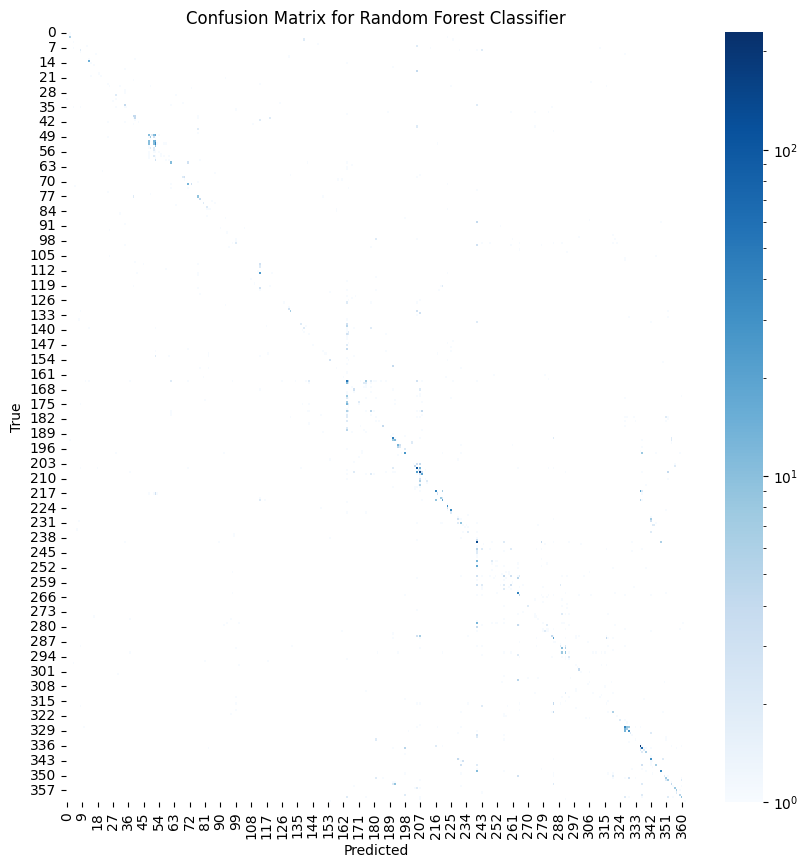

In [26]:
# Matris de confusión eficiente para 397 clases
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=False, cmap="Blues", fmt="g", norm=LogNorm())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Random Forest Classifier")
plt.show()